In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import statsmodels.api as sm

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [49]:
df = pd.read_csv('/content/sales_data.csv')

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [50]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

DATASET INFORMATION

Shape of Dataset
(100, 7)

Columns
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Data Types
Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object

Missing Values
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows
0


In [51]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.head())

        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05      Laptop         8  39835     CUST005  North       318680


In [52]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe(include='all'))

DESCRIPTIVE STATISTICS
                       Date Product    Quantity         Price Customer_ID  \
count                   100     100  100.000000    100.000000         100   
unique                  NaN       5         NaN           NaN         100   
top                     NaN  Tablet         NaN           NaN     CUST001   
freq                    NaN      26         NaN           NaN           1   
mean    2024-02-19 12:00:00     NaN    4.780000  25808.510000         NaN   
min     2024-01-01 00:00:00     NaN    1.000000   1308.000000         NaN   
25%     2024-01-25 18:00:00     NaN    2.750000  14965.250000         NaN   
50%     2024-02-19 12:00:00     NaN    5.000000  24192.000000         NaN   
75%     2024-03-15 06:00:00     NaN    7.000000  38682.250000         NaN   
max     2024-04-09 00:00:00     NaN    9.000000  49930.000000         NaN   
std                     NaN     NaN    2.588163  13917.630242         NaN   

       Region    Total_Sales  
count     100     100

In [53]:
numerical = ['Quantity','Price','Total_Sales']

for col in numerical:

    print("="*60)
    print("Column :",col)
    print("="*60)

    print("Mean :",df[col].mean())

    print("Median :",df[col].median())

    print("Mode :",df[col].mode()[0])

    print("Variance :",df[col].var())

    print("Standard Deviation :",df[col].std())

    print("Minimum :",df[col].min())

    print("Maximum :",df[col].max())

    print("Range :",df[col].max()-df[col].min())

    print("25th Percentile :",df[col].quantile(0.25))

    print("50th Percentile :",df[col].quantile(0.50))

    print("75th Percentile :",df[col].quantile(0.75))

    print("Skewness :",df[col].skew())

    print("Kurtosis :",df[col].kurt())

    print()

Column : Quantity
Mean : 4.78
Median : 5.0
Mode : 4
Variance : 6.698585858585861
Standard Deviation : 2.588162641447763
Minimum : 1
Maximum : 9
Range : 8
25th Percentile : 2.75
50th Percentile : 5.0
75th Percentile : 7.0
Skewness : 0.07297715917209194
Kurtosis : -1.1999524820266472

Column : Price
Mean : 25808.51
Median : 24192.0
Mode : 1308
Variance : 193700431.54535356
Standard Deviation : 13917.630241724111
Minimum : 1308
Maximum : 49930
Range : 48622
25th Percentile : 14965.25
50th Percentile : 24192.0
75th Percentile : 38682.25
Skewness : -0.005833858155656331
Kurtosis : -1.25911060832073

Column : Total_Sales
Mean : 123650.48
Median : 97955.5
Mode : 6540
Variance : 10032243003.464245
Standard Deviation : 100161.08527499213
Minimum : 6540
Maximum : 373932
Range : 367392
25th Percentile : 39517.5
50th Percentile : 97955.5
75th Percentile : 175792.5
Skewness : 0.8784922285609769
Kurtosis : -0.18281709321454587



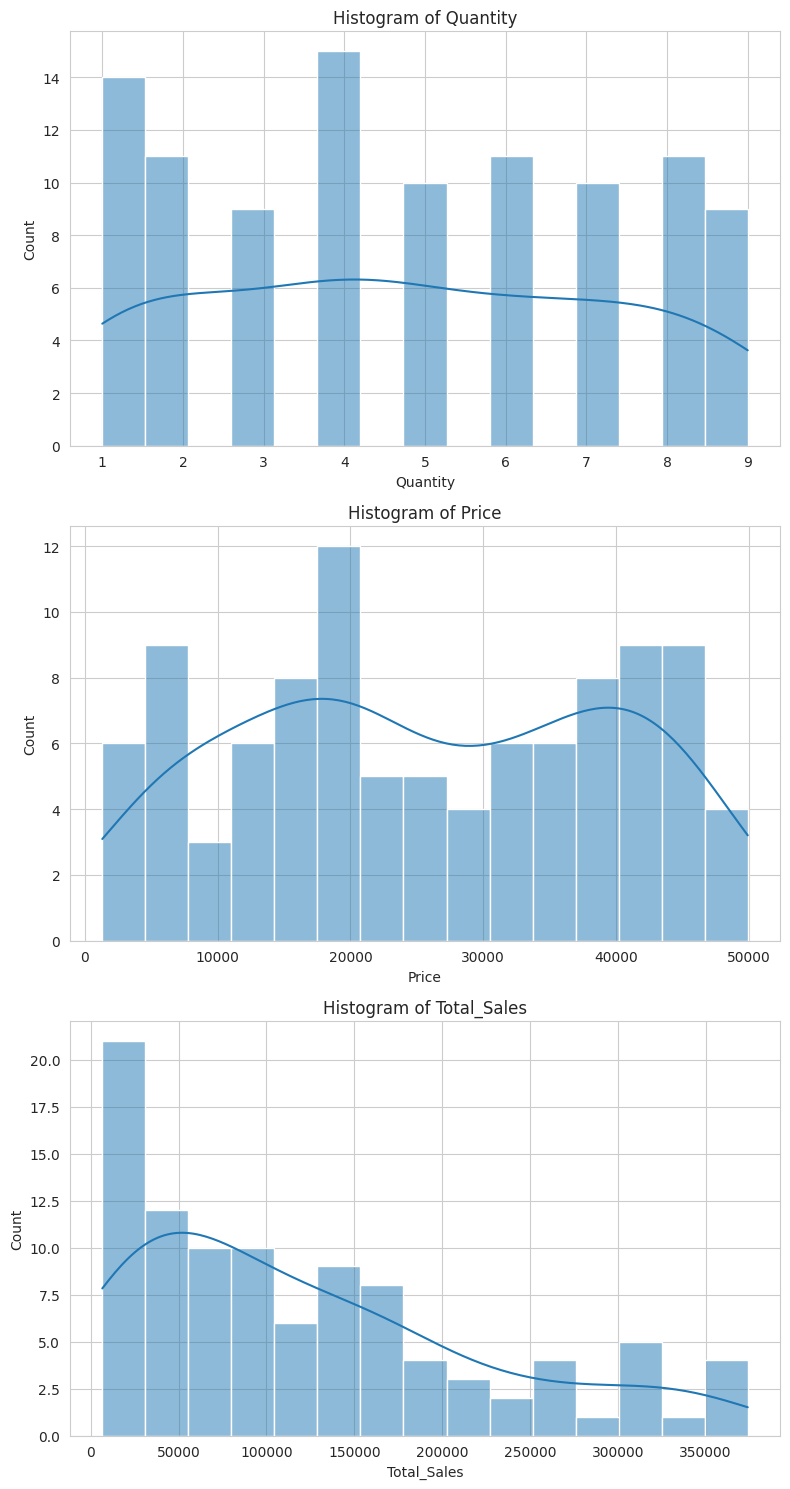

In [55]:
fig, axes = plt.subplots(len(numerical), 1, figsize=(8, 5 * len(numerical)))

for i, col in enumerate(numerical):

    sns.histplot(
        df[col],
        kde=True,
        bins=15,
        ax=axes[i]
    )

    axes[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

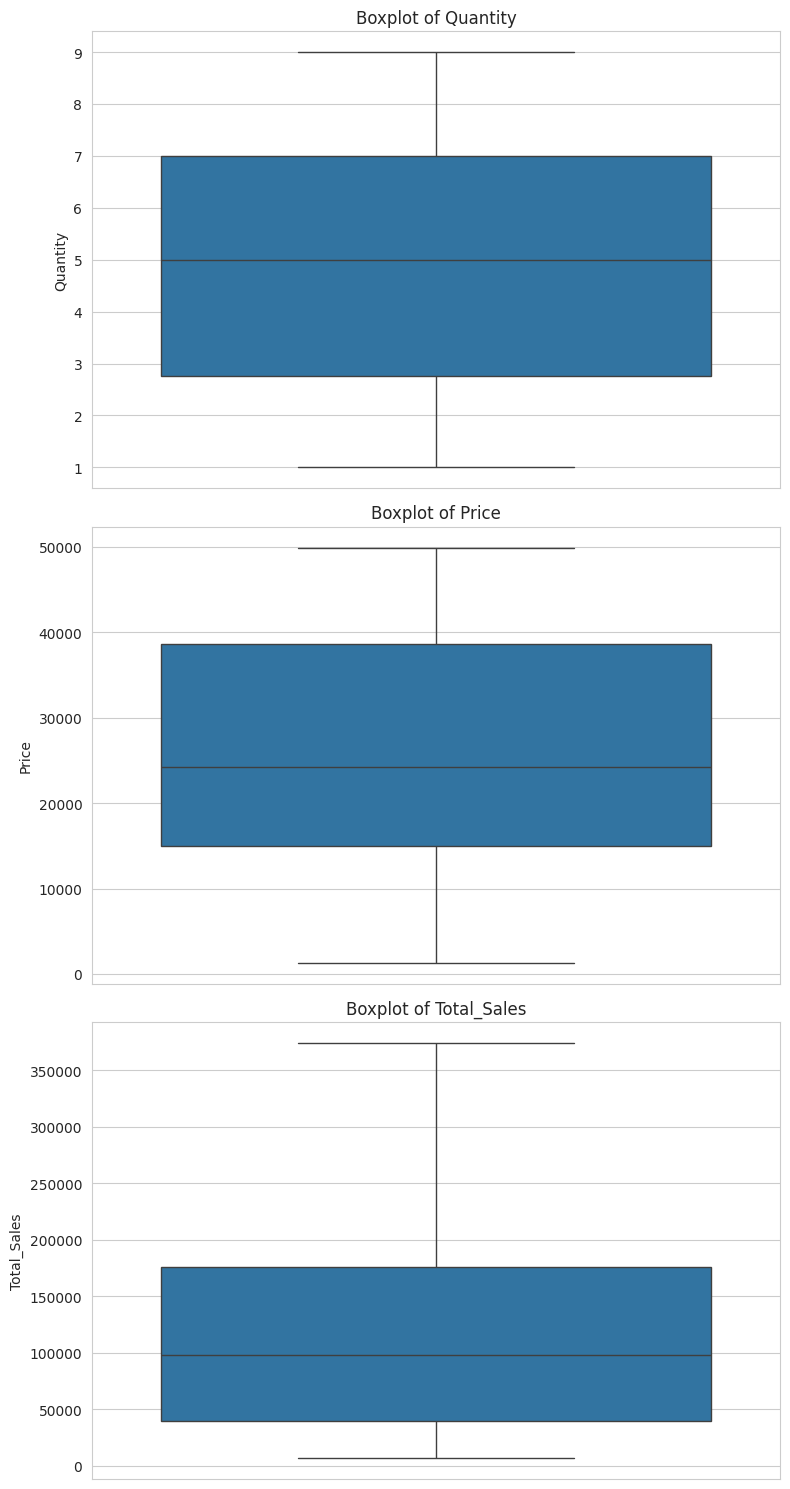

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

for i, col in enumerate(numerical):

    sns.boxplot(y=df[col], ax=axes[i])

    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [57]:
print("="*60)
print("OUTLIER DETECTION USING IQR")
print("="*60)

for col in numerical:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn : {col}")
    print("Lower Limit :", lower)
    print("Upper Limit :", upper)
    print("Number of Outliers :", len(outliers))

OUTLIER DETECTION USING IQR

Column : Quantity
Lower Limit : -3.625
Upper Limit : 13.375
Number of Outliers : 0

Column : Price
Lower Limit : -20610.25
Upper Limit : 74257.75
Number of Outliers : 0

Column : Total_Sales
Lower Limit : -164895.0
Upper Limit : 380205.0
Number of Outliers : 0


In [58]:
print("="*60)
print("NORMALITY TEST (SHAPIRO-WILK)")
print("="*60)

for col in numerical:

    statistic, p = stats.shapiro(df[col])

    print("\n", "="*50)
    print("Column :", col)

    print("Test Statistic :", statistic)
    print("P-value :", p)

    if p > 0.05:
        print("Data follows Normal Distribution")
    else:
        print("Data does NOT follow Normal Distribution")

NORMALITY TEST (SHAPIRO-WILK)

Column : Quantity
Test Statistic : 0.9304459212578251
P-value : 5.2757746484393684e-05
Data does NOT follow Normal Distribution

Column : Price
Test Statistic : 0.9475109921109139
P-value : 0.0005708225317680371
Data does NOT follow Normal Distribution

Column : Total_Sales
Test Statistic : 0.8989262036779536
P-value : 1.2590767205714734e-06
Data does NOT follow Normal Distribution


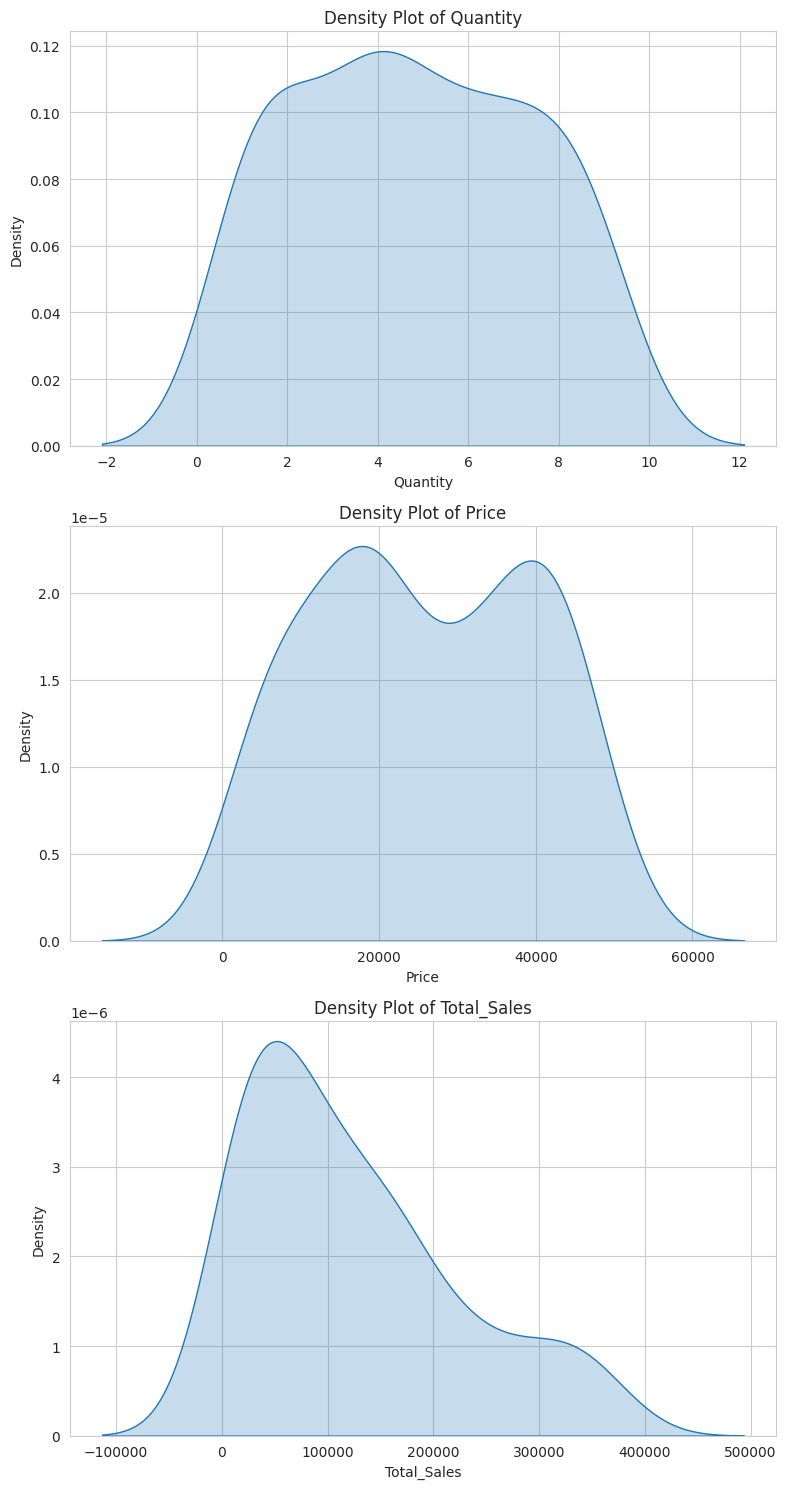

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

for i, col in enumerate(numerical):

    sns.kdeplot(
        df[col],
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Density Plot of {col}')

plt.tight_layout()
plt.show()

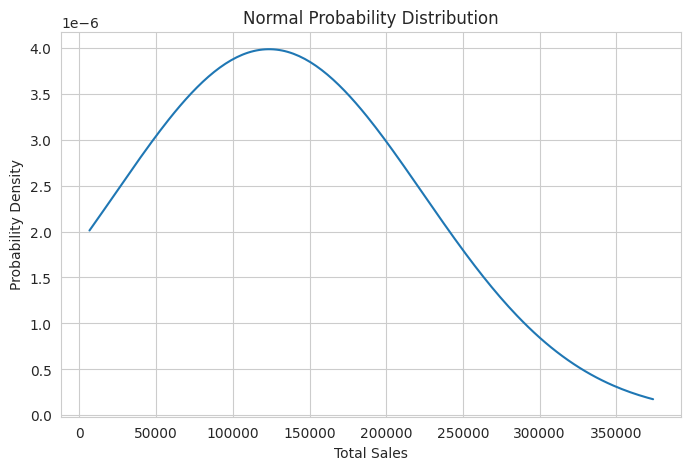

In [61]:
mean = df['Total_Sales'].mean()
std = df['Total_Sales'].std()

x = np.linspace(df['Total_Sales'].min(),
                df['Total_Sales'].max(),
                200)

y = norm.pdf(x, mean, std)

plt.figure(figsize=(8,5))

plt.plot(x, y)

plt.title("Normal Probability Distribution")

plt.xlabel("Total Sales")

plt.ylabel("Probability Density")

plt.show()

In [62]:
print("="*60)
print("PEARSON CORRELATION MATRIX")
print("="*60)

corr = df[['Quantity','Price','Total_Sales']].corr(method='pearson')

print(corr)

print()

print("="*60)
print("COVARIANCE MATRIX")
print("="*60)

cov = df[['Quantity','Price','Total_Sales']].cov()

print(cov)

PEARSON CORRELATION MATRIX
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000

COVARIANCE MATRIX
                  Quantity         Price   Total_Sales
Quantity          6.698586  2.886891e+02  1.783803e+05
Price           288.689091  1.937004e+08  9.007097e+08
Total_Sales  178380.288485  9.007097e+08  1.003224e+10


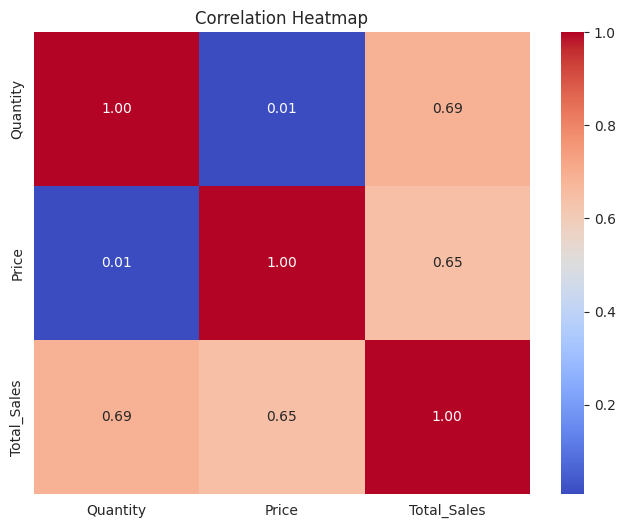

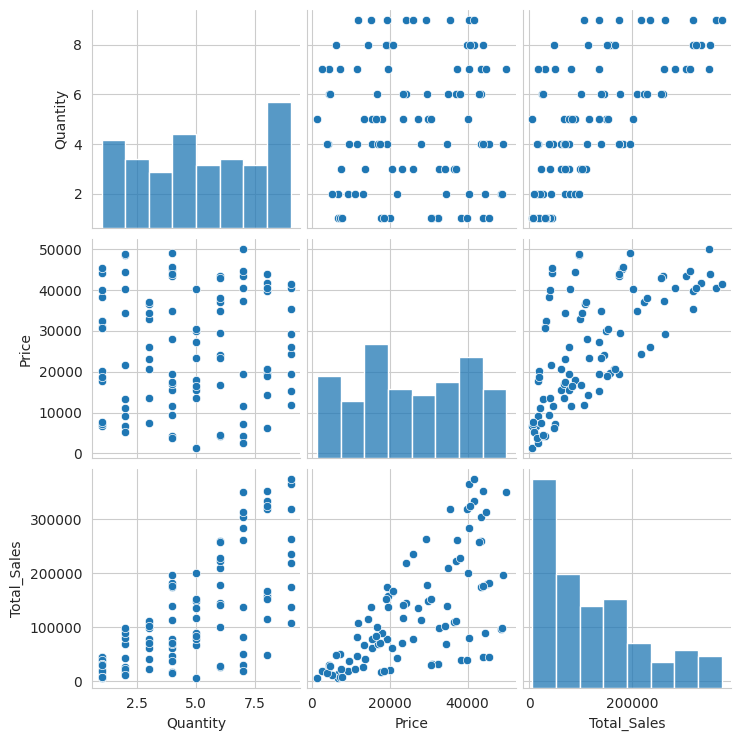

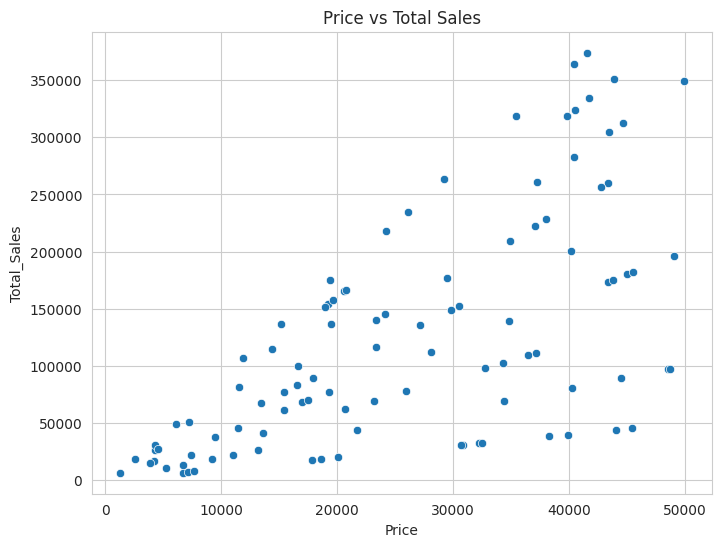

CORRELATION INTERPRETATION
Positive correlation between Price and Total Sales.
Positive correlation between Quantity and Total Sales.


In [65]:

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[['Quantity', 'Price', 'Total_Sales']])
plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Price',
    y='Total_Sales'
)

plt.title("Price vs Total Sales")
plt.show()


print("=" * 60)
print("CORRELATION INTERPRETATION")
print("=" * 60)

if corr.loc['Price', 'Total_Sales'] > 0:
    print("Positive correlation between Price and Total Sales.")
else:
    print("Negative correlation between Price and Total Sales.")

if corr.loc['Quantity', 'Total_Sales'] > 0:
    print("Positive correlation between Quantity and Total Sales.")
else:
    print("Negative correlation between Quantity and Total Sales.")

In [66]:
print("="*70)
print("HYPOTHESIS TEST 1 : ONE SAMPLE T-TEST")
print("="*70)

print("H0 : Mean Total Sales = 150000")
print("H1 : Mean Total Sales ≠ 150000")

t, p = stats.ttest_1samp(df['Total_Sales'],150000)

print("\nT Statistic :",t)
print("P-value :",p)

if p < 0.05:
    print("Result : Reject H0")
    print("The average Total Sales is significantly different from 150000.")
else:
    print("Result : Fail to Reject H0")


print("\n\n")


print("="*70)
print("HYPOTHESIS TEST 2 : INDEPENDENT T-TEST")
print("="*70)

print("H0 : Mean sales of North and South are equal.")
print("H1 : Mean sales of North and South are different.")

north = df[df['Region']=="North"]['Total_Sales']
south = df[df['Region']=="South"]['Total_Sales']

t, p = stats.ttest_ind(north, south, equal_var=False)

print("\nT Statistic :",t)
print("P-value :",p)

if p < 0.05:
    print("Result : Reject H0")
    print("Sales differ significantly between North and South.")
else:
    print("Result : Fail to Reject H0")


print("\n\n")


print("="*70)
print("HYPOTHESIS TEST 3 : ONE-WAY ANOVA")
print("="*70)

print("H0 : Mean sales are equal across all regions.")
print("H1 : At least one region has different mean sales.")

groups = []

for region in df['Region'].unique():

    groups.append(df[df['Region']==region]['Total_Sales'])

F, p = stats.f_oneway(*groups)

print("\nF Statistic :",F)
print("P-value :",p)

if p < 0.05:
    print("Result : Reject H0")
    print("There is a significant difference among regions.")
else:
    print("Result : Fail to Reject H0")

HYPOTHESIS TEST 1 : ONE SAMPLE T-TEST
H0 : Mean Total Sales = 150000
H1 : Mean Total Sales ≠ 150000

T Statistic : -2.6307143066249163
P-value : 0.009882441027151238
Result : Reject H0
The average Total Sales is significantly different from 150000.



HYPOTHESIS TEST 2 : INDEPENDENT T-TEST
H0 : Mean sales of North and South are equal.
H1 : Mean sales of North and South are different.

T Statistic : 0.12990909486062338
P-value : 0.8971521399586031
Result : Fail to Reject H0



HYPOTHESIS TEST 3 : ONE-WAY ANOVA
H0 : Mean sales are equal across all regions.
H1 : At least one region has different mean sales.

F Statistic : 2.164363429897842
P-value : 0.09723678084980039
Result : Fail to Reject H0


In [67]:
print("="*60)
print("95% CONFIDENCE INTERVAL")
print("="*60)

confidence = 0.95

data = df['Total_Sales']

mean = np.mean(data)

sem = stats.sem(data)

confidence_interval = stats.t.interval(
    confidence,
    len(data)-1,
    loc=mean,
    scale=sem
)

print("Sample Mean :", round(mean,2))
print("95% Confidence Interval :", confidence_interval)

95% CONFIDENCE INTERVAL
Sample Mean : 123650.48
95% Confidence Interval : (np.float64(103776.34767158539), np.float64(143524.6123284146))


In [68]:
print("="*60)
print("MARGIN OF ERROR")
print("="*60)

margin_of_error = confidence_interval[1] - mean

print("Margin of Error :", round(margin_of_error,2))

print()

print("Interpretation:")
print(f"We are 95% confident that the true mean Total Sales lies between {confidence_interval[0]:.2f} and {confidence_interval[1]:.2f}.")

MARGIN OF ERROR
Margin of Error : 19874.13

Interpretation:
We are 95% confident that the true mean Total Sales lies between 103776.35 and 143524.61.


In [69]:
print("="*60)
print("LINEAR REGRESSION")
print("="*60)

X = df[['Price']]
y = df['Total_Sales']

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

print()

print("Regression Equation")

print(f"Total Sales = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × Price)")

print()

r2 = r2_score(y, predictions)

print("R² Score :", round(r2,4))

LINEAR REGRESSION
Slope (Coefficient): 4.650014143657133
Intercept: 3640.5434732834547

Regression Equation
Total Sales = 3640.54 + (4.65 × Price)

R² Score : 0.4175


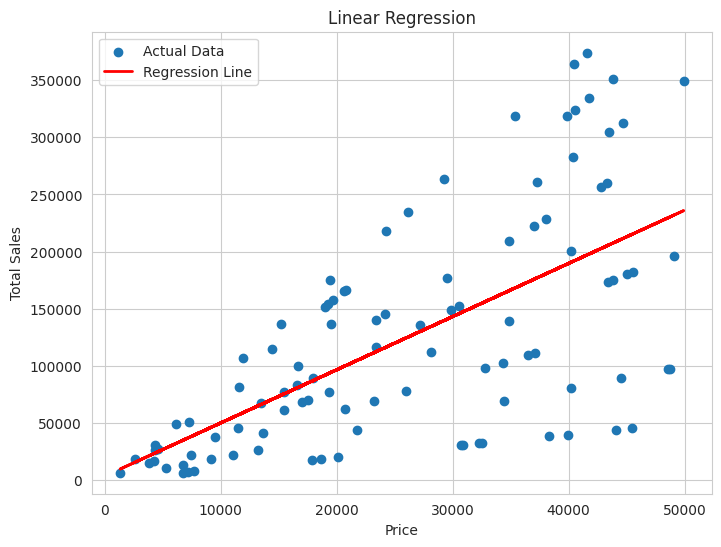

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(df['Price'], df['Total_Sales'], label='Actual Data')

plt.plot(df['Price'], predictions, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Price")

plt.ylabel("Total Sales")

plt.title("Linear Regression")

plt.legend()

plt.show()

In [71]:
print("="*60)
print("OLS REGRESSION SUMMARY")
print("="*60)

X_sm = sm.add_constant(df['Price'])

ols_model = sm.OLS(df['Total_Sales'], X_sm).fit()

print(ols_model.summary())

OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     70.24
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.88e-13
Time:                        06:33:37   Log-Likelihood:                -1265.8
No. Observations:                 100   AIC:                             2536.
Df Residuals:                      98   BIC:                             2541.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3640.5435   1.63e

In [75]:
print("="*70)
print("BUSINESS INSIGHTS")
print("="*70)

print()

print("1. Average Total Sales :", round(df['Total_Sales'].mean(),2))

print()

print("2. Highest Performing Product")

print(df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False))

print()

print("3. Highest Performing Region")

print(df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False))

print()

print("4. Correlation Matrix")

print(df[['Quantity','Price','Total_Sales']].corr())

print()

print("="*70)
print("ACTIONABLE RECOMMENDATIONS")
print("="*70)

print()

print("• Focus marketing efforts on the highest-performing products.")

print("• Increase inventory for products with consistently high sales.")

print("• Prioritize business expansion in the best-performing regions.")

print("• Use pricing strategies based on the regression analysis.")

print("• Monitor sales trends regularly using statistical analysis.")

print("• Investigate regions with lower sales and improve promotional activities.")

print("• Use confidence intervals to estimate future average sales.")

print("• Continue collecting data for more accurate forecasting.")


print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print("Statistical Business Analysis Completed Successfully!")


BUSINESS INSIGHTS

1. Average Total Sales : 123650.48

2. Highest Performing Product
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

3. Highest Performing Region
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

4. Correlation Matrix
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000

ACTIONABLE RECOMMENDATIONS

• Focus marketing efforts on the highest-performing products.
• Increase inventory for products with consistently high sales.
• Prioritize business expansion in the best-performing regions.
• Use pricing strategies based on the regression analysis.
• Monitor sales trends regularly using statistical analysis.
• Investigate regions with lower sales and improve promotional activities.
• Use confi